In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# pip install torchvision
# 

In [5]:
import os,sys
#sys.path.append('/work/qdiff/mo_utils')
sys.executable


'/home/nadavg/phase2-sdk/sdk_virtualenv/bin/python'

In [6]:
print(os.getcwdb())
os.chdir('/home/nadavg/q-diffusion')
print(os.getcwdb())

b'/home/nadavg/q-diffusion/scripts/hf15'
b'/home/nadavg/q-diffusion'


In [7]:
os.environ['CUDA_VISIBLE_DEVICES'] = '4'

In [8]:
import torch
torch.cuda.is_available()

True

In [9]:
from mo_utils.utils.stand_alone_utils.har_utils import get_har_files,get_params_from_har
from mo_utils.utils.stand_alone_utils.pytorch2accelras import (
    get_nested_attr,
    get_weight_and_bias_from_layer_name,
    acc_ker_to_pytorch_weight,
    UpdateUnet,
    )
from mo_utils.utils.stand_alone_utils.quant_utils import calc_snr,calc_stats


In [10]:
from src.utils.torch_utils import add_full_name_to_module
from scripts.hf15.init_pipe import init_pipe

/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/flax/struct.py:136: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/flax/struct.py:136: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
2025-04-01 11:24:00.793887: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/flax/struct.py:136: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, k

In [11]:
import netron
from pathlib import Path
from collections import namedtuple
from pathlib import Path

In [12]:
import torch
import torch.nn as nn
from diffusers import StableDiffusionPipeline
from scripts.hf15.txt2img import get_train_samples
from qdiff.quant_model import QuantModel,init_qnn_from_fp_model

/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


In [13]:
cali_data_path ='/genai/users/nadavg/sd/qdiff_hf15_verb/gen_calib/calib_dict_steps20.pt' 
sample_data = torch.load(cali_data_path)
dummy_args = namedtuple('Args',['cali_n','cali_st','custom_steps','cond'])
opt = dummy_args(1,20,None,True)
cali_data = get_train_samples(opt, sample_data,20)
cali_xs, cali_ts, cali_cs = cali_data

In [14]:
cali_xs.shape,cali_ts.shape,cali_cs.shape   

(torch.Size([40, 4, 64, 64]), torch.Size([40]), torch.Size([40, 77, 768]))

In [15]:
#input_bach = [torch.randn((1, 4, 64, 64)),torch.randn(1),torch.randn((1,77,768))]
#input_bach[0].shape,input_bach[1].shape,input_bach[2].shape

In [13]:
#pipe.to('cuda')

In [16]:
#ace_unet_path =  '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/unet_sim_fp.har'
#ace_unet_path = '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/quant_params/unet_eq_pre_ln.har'
ace_unet_path = '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/quantize_params_10_03/unet_sim_eq.har'
get_har_files(ace_unet_path)

['unet_sim.hn',
 'unet_sim.alls',
 'unet_sim.native.hn',
 'unet_sim.npz',
 'unet_sim.fpo.npz',
 'unet_sim.stats.npz',
 'unet_sim.original_model_meta.json',
 'unet_sim.modifications_meta_data.json',
 'unet_sim.modification_params.npz',
 'unet_sim.metadata.json']

In [17]:
input_bach = [cali_xs[0:1],cali_ts[0:1],cali_cs[0:1]]

In [18]:
qnn,pipe = init_qnn_from_fp_model(har_path=ace_unet_path ,input_batch=input_bach,scheduler='euler')

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, plea

SNR of acceleras fp model : 139.1388159587653 [db]


In [19]:
from scripts.gen_val_images import gen_images
import matplotlib.pyplot as plt

In [20]:
pipe.unet = qnn.model

In [21]:
_=pipe.to('cuda')
I = gen_images(pipe, 4, 20,negative_prompt='default')

young, curly haired, redhead Natalie Portman  as a optimistic!, cheerful, giddy medieval innkeeper in a dark medieval inn. dark shadows, colorful, candle light,  law contrasts, fantasy concept art by Jakub Rozalski, Jan Matejko, and J.Dickenson


  0%|          | 0/20 [00:00<?, ?it/s]

a mystical tribal goddess adorned with feathers and gemstones and cables and synthesizer parts is surrounded by sacred geometry made from elven architecture, full body, gorgeous, perfect face, powerful, cinematic, beautifully lit, by artgerm, by karol bak, 3 d, trending on artstation, octane render, 8 k


  0%|          | 0/20 [00:00<?, ?it/s]

molly millions, portrait of a beautiful cyberpunk woman, sunglasses, shoulder long hair, cyberpunk, street samurai, sunset, neuromancer, cyberpunk city background, megacity, gorgeous view, depth, high detail, digital art, painted by greg rutkowski, painted by seb mckinnon, trending on artstation


...

Token indices sequence length is longer than the specified maximum sequence length for this model (80 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['iny, muted']


front shot of an alien cargo ship, intricate, elegant, highly detailed, centered, artstation, concept art, smooth, sharp focus, artgerm, tomasz alen kopera, peter mohrbacher, donato giancola, joseph christian leyendecker, wlop, boris vallejo ), mugshot, ugly, octane render, nvidia raytracing demo, grainy, muted


  0%|          | 0/20 [00:00<?, ?it/s]

portrait of a young ruggedly handsome but joyful pirate, male, masculine, upper body, red hair, long hair, d & d, fantasy, smirk, intricate, elegant, highly detailed, digital painting, artstation, concept art, matte, sharp focus, illustration, art by artgerm and greg rutkowski and alphonse mucha


  0%|          | 0/20 [00:00<?, ?it/s]

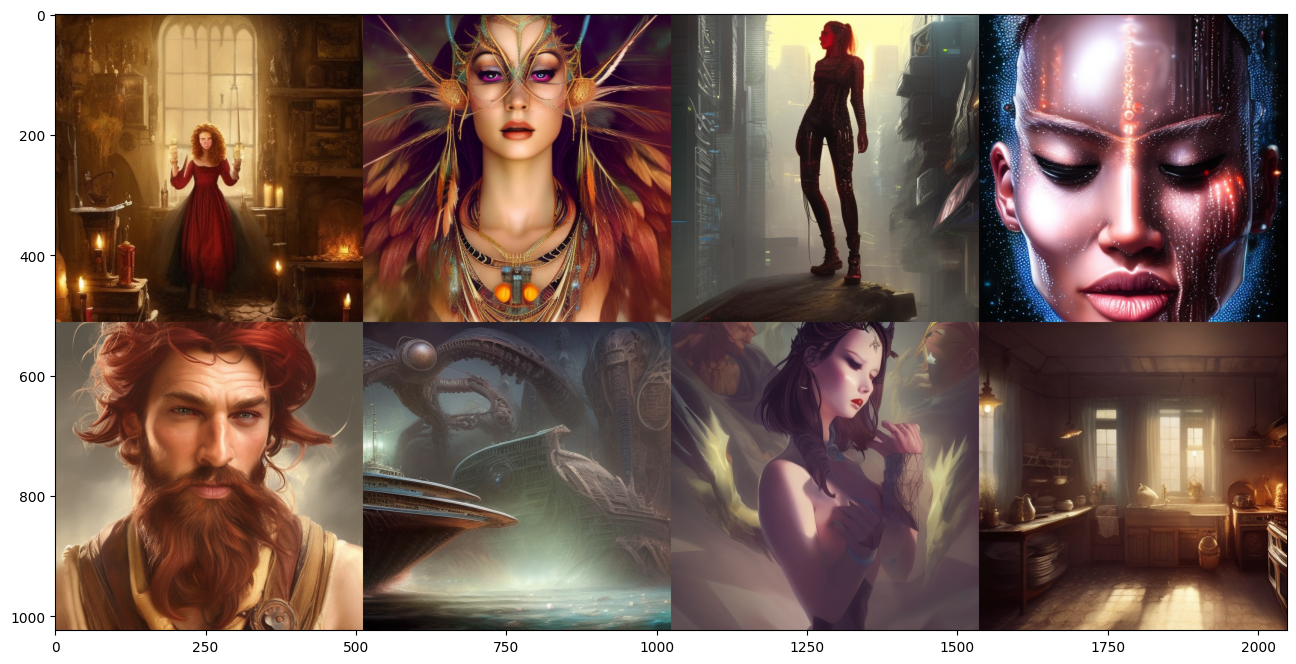

In [22]:
f,ax = plt.subplots(figsize=(32,8))
ax.imshow(I)

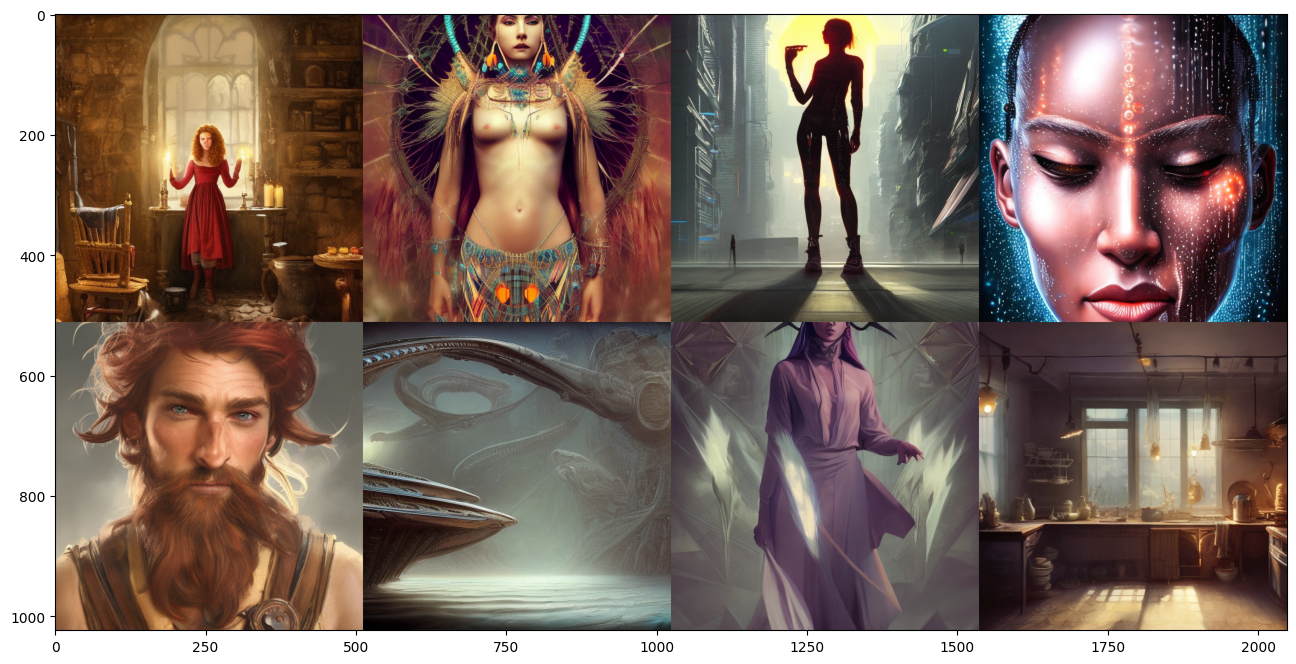

In [ ]:
f,ax = plt.subplots(figsize=(32,8))
ax.imshow(I)

In [27]:
pipe = init_pipe()

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, plea

In [28]:
pipe.to('cuda')
I = gen_images(pipe, 4, 20)

young, curly haired, redhead Natalie Portman  as a optimistic!, cheerful, giddy medieval innkeeper in a dark medieval inn. dark shadows, colorful, candle light,  law contrasts, fantasy concept art by Jakub Rozalski, Jan Matejko, and J.Dickenson


  0%|          | 0/20 [00:00<?, ?it/s]

a mystical tribal goddess adorned with feathers and gemstones and cables and synthesizer parts is surrounded by sacred geometry made from elven architecture, full body, gorgeous, perfect face, powerful, cinematic, beautifully lit, by artgerm, by karol bak, 3 d, trending on artstation, octane render, 8 k


  0%|          | 0/20 [00:00<?, ?it/s]

molly millions, portrait of a beautiful cyberpunk woman, sunglasses, shoulder long hair, cyberpunk, street samurai, sunset, neuromancer, cyberpunk city background, megacity, gorgeous view, depth, high detail, digital art, painted by greg rutkowski, painted by seb mckinnon, trending on artstation


...

Token indices sequence length is longer than the specified maximum sequence length for this model (80 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['iny, muted']


front shot of an alien cargo ship, intricate, elegant, highly detailed, centered, artstation, concept art, smooth, sharp focus, artgerm, tomasz alen kopera, peter mohrbacher, donato giancola, joseph christian leyendecker, wlop, boris vallejo ), mugshot, ugly, octane render, nvidia raytracing demo, grainy, muted


  0%|          | 0/20 [00:00<?, ?it/s]

portrait of a young ruggedly handsome but joyful pirate, male, masculine, upper body, red hair, long hair, d & d, fantasy, smirk, intricate, elegant, highly detailed, digital painting, artstation, concept art, matte, sharp focus, illustration, art by artgerm and greg rutkowski and alphonse mucha


  0%|          | 0/20 [00:00<?, ?it/s]

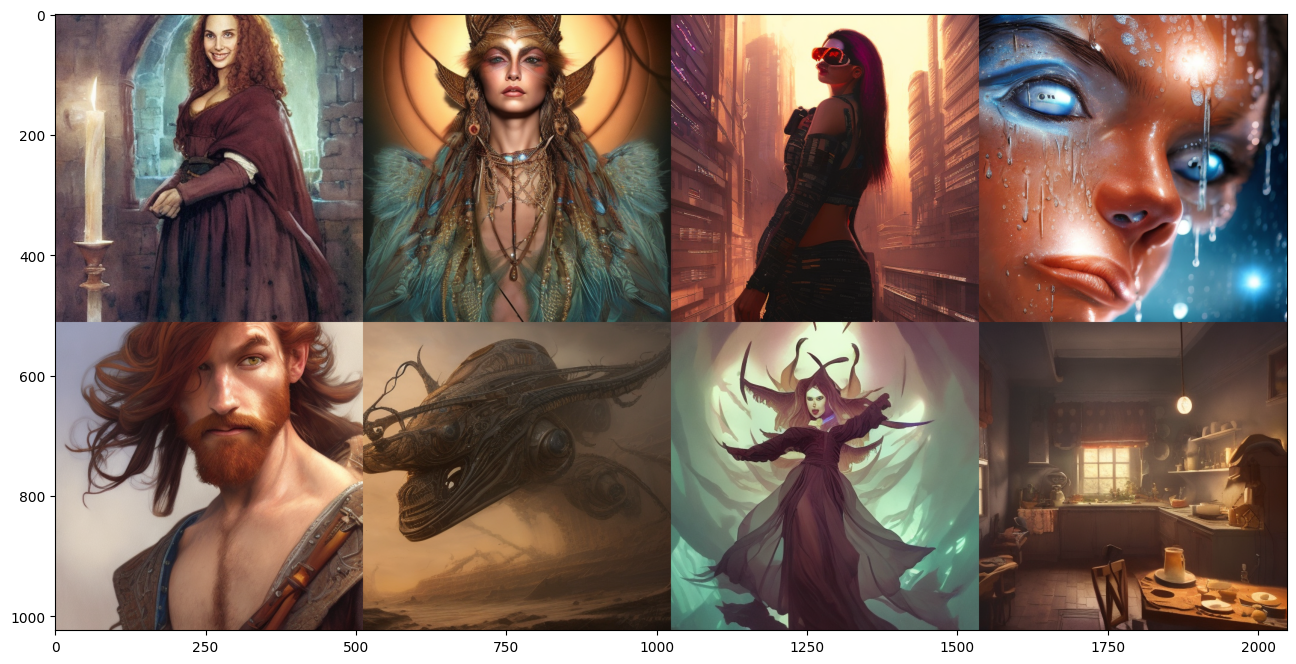

In [29]:
f,ax = plt.subplots(figsize=(32,8))
ax.imshow(I)

In [20]:
from mo_utils.utils.har_utils import super_netron
super_netron(ace_unet_path,port=8050)

all_names=['unet_sim.hn', 'unet_sim.alls', 'unet_sim.native.hn', 'unet_sim.npz', 'unet_sim.fpo.npz', 'unet_sim.stats.npz', 'unet_sim.original_model_meta.json', 'unet_sim.modifications_meta_data.json', 'unet_sim.modification_params.npz', 'unet_sim.metadata.json']
loading  params_name='unet_sim.hn' ...
Serving 'temp.hn' at http://localhost:8050


In [21]:
params = get_params_from_har(ace_unet_path,params_name='unet_sim.fpo.npz')
hn = get_params_from_har(ace_unet_path,params_name='unet_sim.hn')

all_names=['unet_sim.hn', 'unet_sim.alls', 'unet_sim.native.hn', 'unet_sim.npz', 'unet_sim.fpo.npz', 'unet_sim.stats.npz', 'unet_sim.original_model_meta.json', 'unet_sim.modifications_meta_data.json', 'unet_sim.modification_params.npz', 'unet_sim.metadata.json']
loading  params_name='unet_sim.fpo.npz' ...
all_names=['unet_sim.hn', 'unet_sim.alls', 'unet_sim.native.hn', 'unet_sim.npz', 'unet_sim.fpo.npz', 'unet_sim.stats.npz', 'unet_sim.original_model_meta.json', 'unet_sim.modifications_meta_data.json', 'unet_sim.modification_params.npz', 'unet_sim.metadata.json']
loading  params_name='unet_sim.hn' ...


In [44]:
pipe = init_pipe()
unet = pipe.unet
add_full_name_to_module(unet)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, plea

In [45]:
ind_batch= slice(30,31)
#ind_batch= slice(0,1)

In [46]:
out_org = unet(cali_xs[ind_batch],cali_ts[ind_batch],cali_cs[ind_batch])
out_org[0].shape

torch.Size([1, 4, 64, 64])

In [47]:
unet.in_channels

/tmp/ipykernel_70839/3567289933.py:1: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  unet.in_channels


4

In [48]:
uu= UpdateUnet(unet, hn,params)

In [49]:
uu.debug = True
uu.update_unet_convs()


lname=unet_sim/conv1 type=conv
layer_norm_input=False,ff_input=False,kqv=False
layer_name='unet_sim/conv1' : layer_norm_input=False,ff_input=False,kqv=False

lname=unet_sim/fc1 type=dense
layer_norm_input=False,ff_input=False,kqv=False
layer_name='unet_sim/fc1' : layer_norm_input=False,ff_input=False,kqv=False

lname=unet_sim/fc2 type=dense
layer_norm_input=False,ff_input=False,kqv=False
layer_name='unet_sim/fc2' : layer_norm_input=False,ff_input=False,kqv=False

lname=unet_sim/fc10 type=dense
layer_norm_input=False,ff_input=False,kqv=False
layer_name='unet_sim/fc10' : layer_norm_input=False,ff_input=False,kqv=False

lname=unet_sim/fc11 type=dense
layer_norm_input=False,ff_input=False,kqv=False
layer_name='unet_sim/fc11' : layer_norm_input=False,ff_input=False,kqv=False

lname=unet_sim/fc12 type=dense
layer_norm_input=False,ff_input=False,kqv=False
layer_name='unet_sim/fc12' : layer_norm_input=False,ff_input=False,kqv=False

lname=unet_sim/fc13 type=dense
layer_norm_input=False,ff_inp

In [50]:
if False:
    uu.debug = True
    uu.update_conv_weights_and_biases('unet_sim/conv_feature_splitter1_1')
    uu.update_conv_weights_and_biases('unet_sim/conv_feature_splitter1_2')
    uu.update_conv_weights_and_biases('unet_sim/conv_feature_splitter1_3')

In [51]:
out_reorg_unet = unet(cali_xs[ind_batch],cali_ts[ind_batch],cali_cs[ind_batch])


In [16]:
qnn = QuantModel(
    model=unet, weight_quant_params={}, act_quant_params={},)
    #act_quant_mode="qdiff", sm_abit=16,quant_act_ops = opt.quant_act_ops, split=opt.split)

NameError: name 'unet' is not defined

In [53]:
out_reorg_qnn_temp = qnn.model(cali_xs[ind_batch],cali_ts[ind_batch],cali_cs[ind_batch])
calc_snr(out_org[0],out_reorg_qnn_temp[0])

0.49016642524855797

In [54]:
uu= UpdateUnet(qnn.model, hn,params)

In [55]:
uu.update_unet_ew_adds()

In [56]:
out_reorg_qnn = qnn.model(cali_xs[ind_batch],cali_ts[ind_batch],cali_cs[ind_batch])
#out_reorg = unet(cali_xs[ind_batch],cali_ts[ind_batch],cali_cs[ind_batch])

out_reorg_qnn[0].shape

torch.Size([1, 4, 64, 64])

In [57]:
calc_snr(out_org[0],out_reorg_qnn[0]),calc_snr(out_org[0],out_reorg_unet[0])

(136.33390791067453, 0.2957299646955085)

In [20]:
from scripts.gen_val_images import gen_images
import matplotlib.pyplot as plt

In [39]:
#pipe.to('cuda')

In [21]:
pipe.unet = qnn.model

NameError: name 'pipe' is not defined

In [41]:
_=pipe.to('cuda')

In [42]:
pipe.to('cuda')
I = gen_images(pipe, 4, 20)

young, curly haired, redhead Natalie Portman  as a optimistic!, cheerful, giddy medieval innkeeper in a dark medieval inn. dark shadows, colorful, candle light,  law contrasts, fantasy concept art by Jakub Rozalski, Jan Matejko, and J.Dickenson


  0%|          | 0/20 [00:00<?, ?it/s]

a mystical tribal goddess adorned with feathers and gemstones and cables and synthesizer parts is surrounded by sacred geometry made from elven architecture, full body, gorgeous, perfect face, powerful, cinematic, beautifully lit, by artgerm, by karol bak, 3 d, trending on artstation, octane render, 8 k


  0%|          | 0/20 [00:00<?, ?it/s]

molly millions, portrait of a beautiful cyberpunk woman, sunglasses, shoulder long hair, cyberpunk, street samurai, sunset, neuromancer, cyberpunk city background, megacity, gorgeous view, depth, high detail, digital art, painted by greg rutkowski, painted by seb mckinnon, trending on artstation


...

Token indices sequence length is longer than the specified maximum sequence length for this model (80 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['iny, muted']


front shot of an alien cargo ship, intricate, elegant, highly detailed, centered, artstation, concept art, smooth, sharp focus, artgerm, tomasz alen kopera, peter mohrbacher, donato giancola, joseph christian leyendecker, wlop, boris vallejo ), mugshot, ugly, octane render, nvidia raytracing demo, grainy, muted


  0%|          | 0/20 [00:00<?, ?it/s]

portrait of a young ruggedly handsome but joyful pirate, male, masculine, upper body, red hair, long hair, d & d, fantasy, smirk, intricate, elegant, highly detailed, digital painting, artstation, concept art, matte, sharp focus, illustration, art by artgerm and greg rutkowski and alphonse mucha


  0%|          | 0/20 [00:00<?, ?it/s]

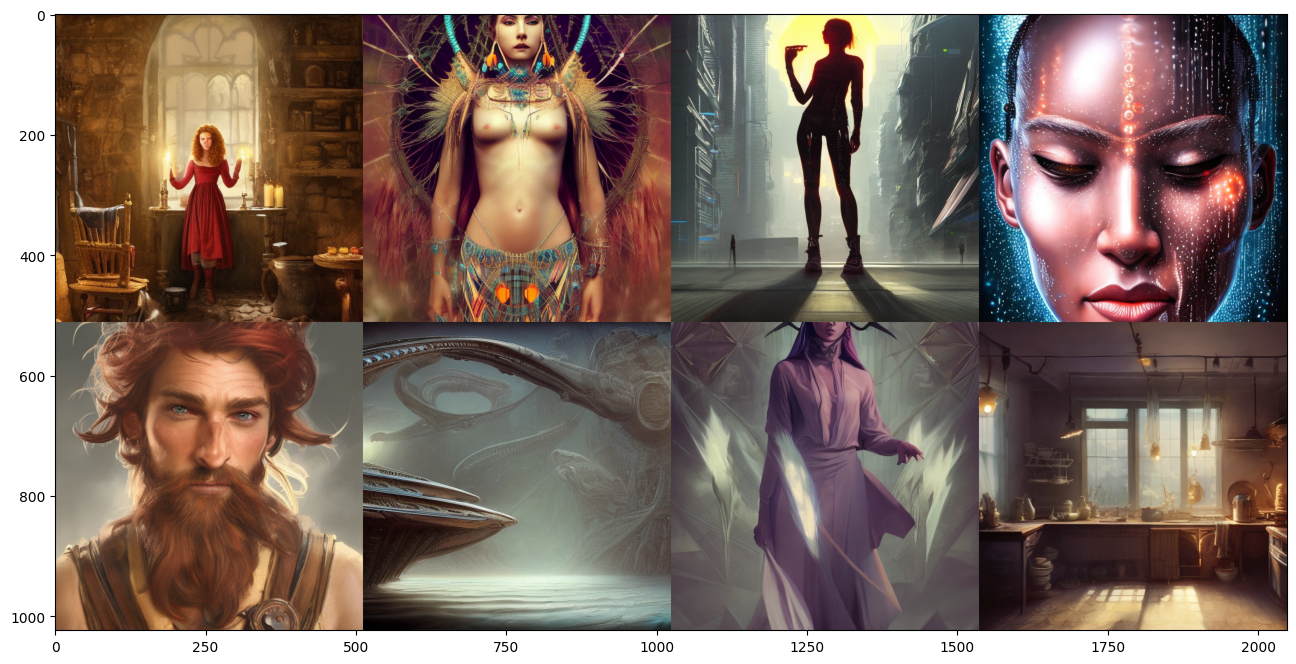

In [43]:
f,ax = plt.subplots(figsize=(32,8))
ax.imshow(I)

In [36]:
pipe = init_pipe()


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, plea

In [37]:
_=pipe.to('cuda')
I = gen_images(pipe, 4, 20)

young, curly haired, redhead Natalie Portman  as a optimistic!, cheerful, giddy medieval innkeeper in a dark medieval inn. dark shadows, colorful, candle light,  law contrasts, fantasy concept art by Jakub Rozalski, Jan Matejko, and J.Dickenson


  0%|          | 0/20 [00:00<?, ?it/s]

a mystical tribal goddess adorned with feathers and gemstones and cables and synthesizer parts is surrounded by sacred geometry made from elven architecture, full body, gorgeous, perfect face, powerful, cinematic, beautifully lit, by artgerm, by karol bak, 3 d, trending on artstation, octane render, 8 k


  0%|          | 0/20 [00:00<?, ?it/s]

molly millions, portrait of a beautiful cyberpunk woman, sunglasses, shoulder long hair, cyberpunk, street samurai, sunset, neuromancer, cyberpunk city background, megacity, gorgeous view, depth, high detail, digital art, painted by greg rutkowski, painted by seb mckinnon, trending on artstation


...

Token indices sequence length is longer than the specified maximum sequence length for this model (80 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['iny, muted']


front shot of an alien cargo ship, intricate, elegant, highly detailed, centered, artstation, concept art, smooth, sharp focus, artgerm, tomasz alen kopera, peter mohrbacher, donato giancola, joseph christian leyendecker, wlop, boris vallejo ), mugshot, ugly, octane render, nvidia raytracing demo, grainy, muted


  0%|          | 0/20 [00:00<?, ?it/s]

portrait of a young ruggedly handsome but joyful pirate, male, masculine, upper body, red hair, long hair, d & d, fantasy, smirk, intricate, elegant, highly detailed, digital painting, artstation, concept art, matte, sharp focus, illustration, art by artgerm and greg rutkowski and alphonse mucha


  0%|          | 0/20 [00:00<?, ?it/s]

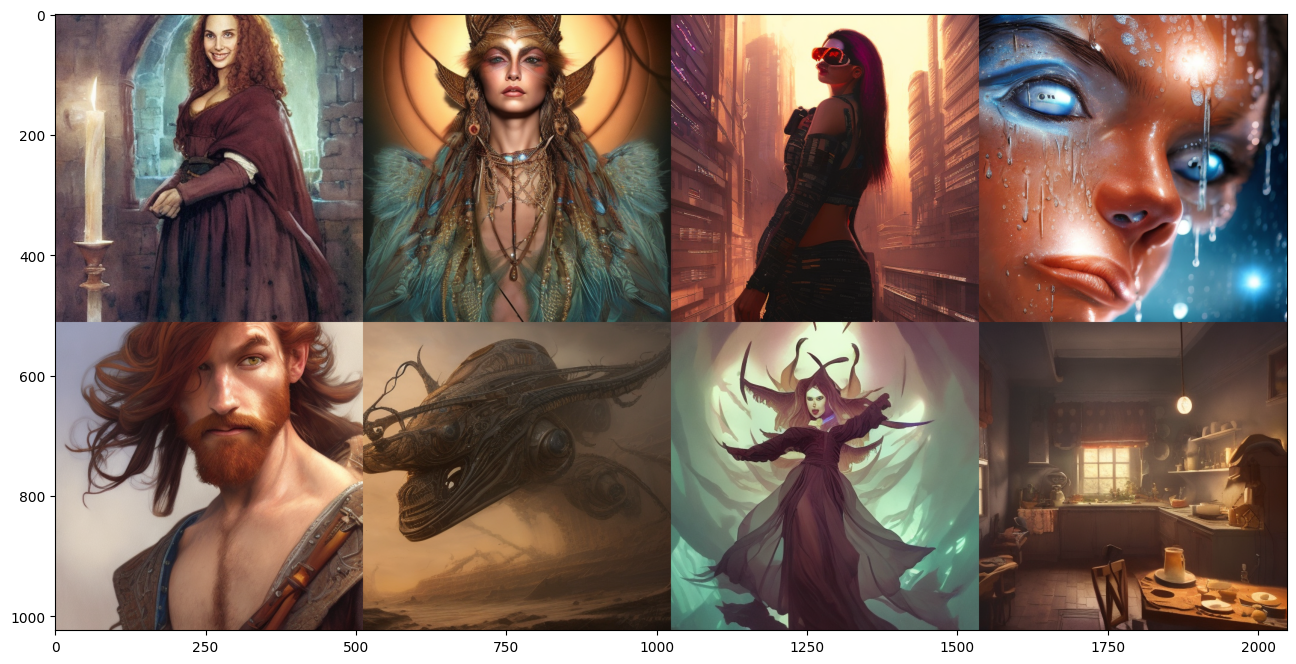

In [38]:
f,ax = plt.subplots(figsize=(32,8))
ax.imshow(I)

In [ ]:
unet.down_blocks[0].attentions[0].ew_add_1.kernel_1.shape

torch.Size([1, 320, 1, 1])

In [ ]:
type(unet.down_blocks[0].attentions[0])#/Add

diffusers.models.transformers.transformer_2d.Transformer2DModel

In [73]:
ew_adds = []
for lname in hn['layers']:
    if hn['layers'][lname]['type'] == 'ew_add':
        #print(f"{lname} ,{hn['layers'][lname]['original_names']}")
        ew_adds.append((lname.split('/')[1],hn['layers'][lname]['original_names'][0]))
ew_adds[:20]
        

[('ew_add1', '/down_blocks.0/resnets.0/Add'),
 ('ew_add2', '/down_blocks.0/resnets.0/Add_1'),
 ('ew_add3', '/down_blocks.0/attentions.0/transformer_blocks.0/Add'),
 ('ew_add4', '/down_blocks.0/attentions.0/transformer_blocks.0/Add_1'),
 ('ew_add5', '/down_blocks.0/attentions.0/transformer_blocks.0/Add_2'),
 ('ew_add6', '/down_blocks.0/attentions.0/Add'),
 ('ew_add7', '/down_blocks.0/resnets.1/Add'),
 ('ew_add8', '/down_blocks.0/resnets.1/Add_1'),
 ('ew_add9', '/down_blocks.0/attentions.1/transformer_blocks.0/Add'),
 ('ew_add10', '/down_blocks.0/attentions.1/transformer_blocks.0/Add_1'),
 ('ew_add11', '/down_blocks.0/attentions.1/transformer_blocks.0/Add_2'),
 ('ew_add12', '/down_blocks.0/attentions.1/Add'),
 ('ew_add13', '/down_blocks.1/resnets.0/Add'),
 ('ew_add14', '/down_blocks.1/resnets.0/Add_1'),
 ('ew_add15', '/down_blocks.1/attentions.0/transformer_blocks.0/Add'),
 ('ew_add16', '/down_blocks.1/attentions.0/transformer_blocks.0/Add_1'),
 ('ew_add17', '/down_blocks.1/attentions.0/

In [75]:
lname,org_name  = ew_adds[2]
lname,org_name 

('ew_add3', '/down_blocks.0/attentions.0/transformer_blocks.0/Add')

In [49]:
ew_add_shapes=[]
for lname in hn['layers']:
    if hn['layers'][lname]['type'] == 'ew_add':
        ew_add_shapes.append(hn['layers'][lname]['output_shapes'][0])

In [50]:
ew_add_shapes

[[-1, 64, 64, 320],
 [-1, 64, 64, 320],
 [-1, 1, 4096, 320],
 [-1, 1, 4096, 320],
 [-1, 1, 4096, 320],
 [-1, 64, 64, 320],
 [-1, 64, 64, 320],
 [-1, 64, 64, 320],
 [-1, 1, 4096, 320],
 [-1, 1, 4096, 320],
 [-1, 1, 4096, 320],
 [-1, 64, 64, 320],
 [-1, 32, 32, 640],
 [-1, 32, 32, 640],
 [-1, 1, 1024, 640],
 [-1, 1, 1024, 640],
 [-1, 1, 1024, 640],
 [-1, 32, 32, 640],
 [-1, 32, 32, 640],
 [-1, 32, 32, 640],
 [-1, 1, 1024, 640],
 [-1, 1, 1024, 640],
 [-1, 1, 1024, 640],
 [-1, 32, 32, 640],
 [-1, 16, 16, 1280],
 [-1, 16, 16, 1280],
 [-1, 1, 256, 1280],
 [-1, 1, 256, 1280],
 [-1, 1, 256, 1280],
 [-1, 16, 16, 1280],
 [-1, 16, 16, 1280],
 [-1, 16, 16, 1280],
 [-1, 1, 256, 1280],
 [-1, 1, 256, 1280],
 [-1, 1, 256, 1280],
 [-1, 16, 16, 1280],
 [-1, 8, 8, 1280],
 [-1, 8, 8, 1280],
 [-1, 8, 8, 1280],
 [-1, 8, 8, 1280],
 [-1, 8, 8, 1280],
 [-1, 8, 8, 1280],
 [-1, 1, 64, 1280],
 [-1, 1, 64, 1280],
 [-1, 1, 64, 1280],
 [-1, 8, 8, 1280],
 [-1, 8, 8, 1280],
 [-1, 8, 8, 1280],
 [-1, 8, 8, 1280],
 [-1, 

In [86]:
ew_add_shape = hn['layers']['unet_sim/'+lname]['output_shapes'][0]
ew_add_shape

[-1, 1, 4096, 320]

In [76]:
ker,bias,kk,bk = get_weight_and_bias_from_layer_name(
                                        lname,params)
ker.shape

(2, 320)

In [77]:
str2num = {'':1 ,'_1':2,'_2':3,}
str2num[org_name.split('Add')[-1]]#.split('_')[0]

1

In [78]:
org_name.split('Add')[0].split('.')[-2].split('/')[-1]

'transformer_blocks'

In [79]:
blocks_name = org_name.split('Add')[0].split('.')[-2].split('/')[-1]
blocks_num = int(org_name.split('Add')[0].split('.')[-1].split('/')[0])
ew_add_num = str2num[org_name.split('Add')[-1]]
blocks_name,blocks_num,ew_add_num



('transformer_blocks', 0, 1)

In [80]:
module = get_nested_attr(qnn.model,org_name,ignore_last=1)
type(module),module.full_name

(qdiff.quant_block.QuantBasicTransformerBlock,
 'down_blocks.0.attentions.0.transformer_blocks.0')

In [81]:
ew_add_module = getattr(module,f'ew_add_{ew_add_num}')

In [91]:
lname,ew_add_module.full_name,ew_add_module.kernel_1.shape,ew_add_module.kernel_2.shape#ew_add_module.in1_name,ew_add_module.in2_name

('ew_add3',
 'down_blocks.0.attentions.0.transformer_blocks.0.ew_add_1',
 torch.Size([1, 4096, 1]),
 torch.Size([1, 4096, 1]))

In [ ]:
def update_ew_add_kernel(ew_add,ker,flip_inputs=False):
    ew_add.kernel_1 = nn.Parameter(ker[:1,:])
    ew_add.kernel_2 = nn.Parameter(ker[1:,:])
    if flip_inputs:
        ew_add.kernel_1,ew_add.kernel_2 = ew_add.kernel_2,ew_add.kernel_1
    ew_add.inited = True

In [ ]:
if blocks_name == 'resnets':
    if ew_add_num == 1 or ew_add_num == 2:
        update_ew_add_kernel(ew_add_module,ker,flip_inputs=False)
    else:
        raise ValueError('wrong ew_add_num {lname}:{org_name}')
elif blocks_name == 'transformer_blocks':
    if ew_add_num in (1,2,3):
        update_ew_add_kernel(ew_add_module,ker,flip_inputs=False)
    else:
        raise ValueError('wrong ew_add_num {lname}:{org_name}')
elif blocks_name == 'attentions':
    if ew_add_num == 1:
        update_ew_add_kernel(ew_add_module,ker,flip_inputs=False)
    else:
        raise ValueError('wrong ew_add_num {lname}:{org_name}')
else:
    raise ValueError('wrong blocks_name {lname}:{org_name}')

        
        


In [151]:
import re
pattern = r".*attentions\.\d+/Add"
filtered = [s for s in ew_adds if re.match(pattern, s)]

In [155]:
len(filtered)

16

In [153]:
type(unet.down_blocks[0].attentions[0])

diffusers.models.transformers.transformer_2d.Transformer2DModel

In [154]:
from diffusers.models.transformers.transformer_2d import Transformer2DModel
for module in unet.modules():
    if isinstance(module, Transformer2DModel):
        print(module.full_name)

down_blocks.0.attentions.0
down_blocks.0.attentions.1
down_blocks.1.attentions.0
down_blocks.1.attentions.1
down_blocks.2.attentions.0
down_blocks.2.attentions.1
up_blocks.1.attentions.0
up_blocks.1.attentions.1
up_blocks.1.attentions.2
up_blocks.2.attentions.0
up_blocks.2.attentions.1
up_blocks.2.attentions.2
up_blocks.3.attentions.0
up_blocks.3.attentions.1
up_blocks.3.attentions.2
mid_block.attentions.0


In [131]:
unet.down_blocks[0].attentions[0].transformer_blocks[0]

BasicTransformerBlock(
  (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
  (attn1): Attention(
    (to_q): Linear(in_features=320, out_features=320, bias=True)
    (to_k): Linear(in_features=320, out_features=320, bias=True)
    (to_v): Linear(in_features=320, out_features=320, bias=True)
    (to_out): ModuleList(
      (0): Linear(in_features=320, out_features=320, bias=True)
      (1): Dropout(p=0.0, inplace=False)
    )
  )
  (norm2): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
  (attn2): Attention(
    (to_q): Linear(in_features=320, out_features=320, bias=True)
    (to_k): Linear(in_features=768, out_features=320, bias=True)
    (to_v): Linear(in_features=768, out_features=320, bias=True)
    (to_out): ModuleList(
      (0): Linear(in_features=320, out_features=320, bias=True)
      (1): Dropout(p=0.0, inplace=False)
    )
  )
  (norm3): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
  (ff): FeedForward(
    (net): ModuleList(
      (0): GEGLU(
    

In [135]:
hn['layers']['unet_sim/ew_add6']#['unet_sim/pre_ln_equalization_consumer_layer_normalization1']

{'type': 'ew_add',
 'input': ['unet_sim/conv43', 'unet_sim/ew_add2'],
 'output': ['unet_sim/layer_normalization7',
  'unet_sim/ew_add8',
  'unet_sim/concat11'],
 'input_shapes': [[-1, 64, 64, 320], [-1, 64, 64, 320]],
 'output_shapes': [[-1, 64, 64, 320], [-1, 64, 64, 320], [-1, 64, 64, 320]],
 'original_names': ['/down_blocks.0/attentions.0/Add'],
 'compilation_params': {},
 'quantization_params': {},
 'params': {'activation': 'linear'}}

In [136]:
kk = get_weight_and_bias_from_layer_name('unet_sim/ew_add6',params)

In [137]:
kk[0].shape

(2, 320)

In [138]:
kk

(array([[0.6508667 , 0.4324474 , 0.62527245, 0.53761935, 0.49592108,
         0.74712396, 0.5988764 , 0.6155368 , 0.55012804, 0.6660336 ,
         0.5497085 , 0.52433836, 0.50132483, 0.45594534, 0.45953166,
         0.6003075 , 0.5531531 , 0.49818906, 0.64487505, 0.53315187,
         0.47328696, 0.57157534, 0.6489115 , 0.6082118 , 0.53938323,
         0.63889825, 0.5116935 , 0.5855343 , 0.60397696, 0.603928  ,
         0.5922177 , 0.5322571 , 0.52163106, 0.54891735, 0.6932824 ,
         0.53114253, 0.78002197, 0.50853246, 0.493087  , 0.4428047 ,
         0.50129914, 0.8522196 , 0.6540777 , 0.7065446 , 0.6043314 ,
         0.7139596 , 0.50877917, 0.44454166, 0.68348056, 0.45622683,
         0.5883237 , 0.72236466, 0.5658723 , 0.36987412, 0.48882002,
         0.71273196, 0.7869005 , 0.5266053 , 0.67443395, 0.46941167,
         0.48659858, 0.63856953, 0.5649941 , 0.45385498, 0.6227519 ,
         0.5784158 , 0.427845  , 0.58866394, 0.6060513 , 0.47886413,
         0.5032178 , 0.65349734, 0

In [106]:
zw,zb = uu.find_erased_weights_and_biases()

In [107]:
zw,zb

([],
 ['down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q',
  'down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k',
  'down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_v',
  'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_q',
  'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_k',
  'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_v',
  'down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_q',
  'down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_k',
  'down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_v',
  'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_q',
  'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_k',
  'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_v',
  'down_blocks.1.attentions.0.transformer_blocks.0.attn1.to_q',
  'down_blocks.1.attentions.0.transformer_blocks.0.attn1.to_k',
  'down_blocks.1.attentions.0.transformer_blocks.0.attn1.to_v',
  'down_blocks.1.attentions.0.trans

In [108]:
uu.erase_weights_and_biases()

Erased weights for <class 'torch.nn.modules.conv.Conv2d'> : conv_in 
Erased bias for <class 'torch.nn.modules.conv.Conv2d'> : conv_in 
Erased weights for <class 'torch.nn.modules.linear.Linear'> : time_embedding.linear_1 
Erased bias for <class 'torch.nn.modules.linear.Linear'> : time_embedding.linear_1 
Erased weights for <class 'torch.nn.modules.linear.Linear'> : time_embedding.linear_2 
Erased bias for <class 'torch.nn.modules.linear.Linear'> : time_embedding.linear_2 
Erased weights for <class 'torch.nn.modules.conv.Conv2d'> : down_blocks.0.attentions.0.proj_in 
Erased bias for <class 'torch.nn.modules.conv.Conv2d'> : down_blocks.0.attentions.0.proj_in 
Erased weights for <class 'torch.nn.modules.linear.Linear'> : down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q 
Erased weights for <class 'torch.nn.modules.linear.Linear'> : down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k 
Erased weights for <class 'torch.nn.modules.linear.Linear'> : down_blocks.0.attentions.0.t

In [109]:
unet.up_blocks[3].attentions[1].transformer_blocks[0].ff.net[0].proj.weight#.shape

Parameter containing:
tensor([[0., -0., 0.,  ..., 0., -0., -0.],
        [-0., -0., 0.,  ..., -0., -0., -0.],
        [-0., 0., 0.,  ..., 0., -0., -0.],
        ...,
        [0., 0., 0.,  ..., -0., -0., 0.],
        [-0., 0., -0.,  ..., -0., 0., 0.],
        [-0., -0., -0.,  ..., -0., 0., 0.]], requires_grad=True)

In [100]:
uu.debug = True
uu.update_conv_weights_and_biases('unet_sim/conv226')


lname=unet_sim/conv226 type=conv
layer_norm_input=False,ff_input=False,kqv=False
layer_name='unet_sim/conv226', type(module)=<class 'torch.nn.modules.conv.Conv2d'>


In [110]:
uu.debug = False
uu.update_unet()

layer_name='unet_sim/conv1', type(module)=<class 'torch.nn.modules.conv.Conv2d'>
layer_name='unet_sim/fc1', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_sim/fc2', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_sim/fc10', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_sim/fc11', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_sim/fc12', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_sim/fc13', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_sim/fc14', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_sim/fc15', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_sim/fc16', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_sim/fc17', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_sim/fc18', type(module)=<class 'torch.nn.modules.linear.Linear'>
layer_name='unet_si

In [111]:
zwa,zba = uu.find_erased_weights_and_biases()

In [112]:
zwa

['down_blocks.0.attentions.0.norm',
 'down_blocks.0.attentions.0.transformer_blocks.0.norm1',
 'down_blocks.0.attentions.0.transformer_blocks.0.norm2',
 'down_blocks.0.attentions.0.transformer_blocks.0.norm3',
 'down_blocks.0.attentions.1.norm',
 'down_blocks.0.attentions.1.transformer_blocks.0.norm1',
 'down_blocks.0.attentions.1.transformer_blocks.0.norm2',
 'down_blocks.0.attentions.1.transformer_blocks.0.norm3',
 'down_blocks.1.attentions.0.norm',
 'down_blocks.1.attentions.0.transformer_blocks.0.norm1',
 'down_blocks.1.attentions.0.transformer_blocks.0.norm2',
 'down_blocks.1.attentions.0.transformer_blocks.0.norm3',
 'down_blocks.1.attentions.1.norm',
 'down_blocks.1.attentions.1.transformer_blocks.0.norm1',
 'down_blocks.1.attentions.1.transformer_blocks.0.norm2',
 'down_blocks.1.attentions.1.transformer_blocks.0.norm3',
 'down_blocks.2.attentions.0.norm',
 'down_blocks.2.attentions.0.transformer_blocks.0.norm1',
 'down_blocks.2.attentions.0.transformer_blocks.0.norm2',
 'down_b

In [74]:
unet.down_blocks[0].attentions[0].norm.weight

In [113]:
out_reorg = unet(cali_xs[:1],cali_ts[:1],cali_cs[:1])

In [114]:
calc_snr(out_org[0].detach().numpy(),out_reorg[0].detach().numpy())

34.16561365414778

In [21]:
calc_stats(out_org[0].detach().numpy()-out_reorg[0].detach().numpy())

Stats(L1=0.015276389, L2=0.019697933, mean=0.0047007473, std=0.019128812, min=-0.08348107, max=0.07319212, range=0.1566732)

In [ ]:
calc_stats(out_org[0].detach().numpy())

In [ ]:
uu.hn['unet_sim/conv1']

In [ ]:
uu.hn.keys()

In [ ]:
types_modules = dict()
for module in unet.modules():
    if type(module) not in types_modules:
        types_modules[type(module)] = module.full_name
    


In [ ]:
#types_modules

In [ ]:
ace_unet_path =  '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/unet_sim_fp.har'

In [ ]:
get_har_files(ace_unet_path)

In [ ]:
params = get_params_from_har(ace_unet_path,params_name='unet_sim.fpo.npz')
hn = get_params_from_har(ace_unet_path,params_name='unet_sim.hn')

In [ ]:
type(hn['layers'])

In [ ]:
#ii=iter(hn['layers'])
layer

In [ ]:
types_layers = dict()
for layer_name , layer in hn['layers'].items():
    if layer['type'] not in types_layers:
        types_layers[layer['type']] = layer_name

In [ ]:
types_layers

In [ ]:
layers_names = list(hn['layers'].keys())
layers_names[:10]

In [ ]:
#get_nested_attr,
ind =73
ker,bais,kk,bk=get_weight_and_bias_from_layer_name(layers_names[ind],params)
if ker is not None:
    print(ker.shape)
if bais is not None:
    print(bais.shape)
print(kk,bk)
print(f'lname={layers_names[ind]} type={hn["layers"][layers_names[ind]]["type"]}')
org_names =hn['layers'][layers_names[ind]]['original_names']
print(f'{org_names=}')

In [ ]:
# 1. if type = layer_normalization  - do nothing
# 2. if type = normalization -> find the layer normalization layer and update weights and bias
# 1. if LayerNormalization in org_names[0] and len(org_names)>1:
#  norm are inside conv values.

In [ ]:
def get_relevent_orig_name(org_names,):
    for org_name in org_names:
        if 'LayerNormalization' in org_name:
            return org_name
    return None

In [ ]:
get_nested_attr(unet,layers_names[ind])

In [ ]:
layers_names[ind]

In [ ]:
params.keys()

In [ ]:
[k for k in params.keys() if layers_names[ind] in k]

In [ ]:
# update conv layer. 
ind =608 #362#357
ker,bias,kk,bk=get_weight_and_bias_from_layer_name(layers_names[ind],params)
if ker is not None:
    print(ker.shape)
if bias is not None:
    print(bias.shape)
print(kk,bk)
print(f'lname={layers_names[ind]} type={hn["layers"][layers_names[ind]]["type"]}')
org_names =hn['layers'][layers_names[ind]]['original_names']
print(f'{org_names=}')


In [ ]:
layer_norm_input = False
ff_input = False
kqv = False
if any('layer_normalization' in s for s in hn['layers'][layers_names[ind]]['input']):
    layer_norm_input = True
    if 'conv_feature_splitter' in layers_names[ind]:
        kqv = True
if any (['ff' in on for on  in org_names]):
    ff_input = True
print(f'{layer_norm_input=},{ff_input=},{kqv=}')
    

In [ ]:
org_names

In [ ]:
if layer_norm_input is False and ff_input is False:
    module = get_nested_attr(unet,org_names[0])
    p_weights = module.weight.data#.shape,
    p_bias = module.bias.data#.shape
    #p_weights.shape,p_weights.shape
    assert(p_weights.numel() == ker.size)
    assert(p_bias.numel() == bias.size)
    p_ker = acc_ker_to_pytorch_weight(ker)
    assert(p_weights.shape == p_ker.shape)
    module.weight.data =  p_ker
    module.bias.data =  torch.from_numpy(bias).reshape(p_bias.shape)

In [ ]:
if layer_norm_input and kqv :
    if layers_names[ind].endswith('_1'):
        suffix = 'to_k'
    elif layers_names[ind].endswith('_2'):
        suffix = 'to_q'
    elif layers_names[ind].endswith('_3'):
        suffix = 'to_v'
    else:
        raise ValueError(f'layer name {layers_names[ind]} should end with _1 or _2 or _3')
    
    org_name_=None
    for org_name in org_names:
        if 'attn' in org_name:
            org_name_ = org_name
            break
    assert(org_name_ is not None)
    attn_org_name = org_name_.rpartition("/")[0] 
    org_name = attn_org_name+ '/' + suffix
    module = get_nested_attr(unet,org_name,ignore_last=0)
    p_weights = module.weight.data#.shape,
    if module.bias is not None:
        p_bias = module.bias.data
    else:
        p_bias = None
    assert(p_weights.numel() == ker.size)
    if p_bias is not None:
        assert(p_bias.numel() == bias.size)
    p_ker = acc_ker_to_pytorch_weight(ker)
    assert(p_weights.shape == p_ker.shape)
    module.weight.data =  p_ker
    if bias is not None:
        if p_bias is not None:
            module.bias.data =  torch.from_numpy(bias).reshape(p_bias.shape)
        else:
            module.bias =  nn.Parameter(torch.from_numpy(bias).reshape(-1))
    else:
        module.bias = None
    
    ## remove weight and bias from layer_normalization. 
    norm_name = attn_org_name.rpartition("/")[0]+f'.norm{attn_org_name.rpartition("/")[2][-1]}'
    norm = get_nested_attr(unet,norm_name,ignore_last=0)
    norm.weight = None
    norm.bias = None 


    

In [ ]:
if layer_norm_input and  kqv is False and ff_input is False : 
    # attn2 (only?)
    suffix = 'to_q'
    org_name_=None
    for org_name in org_names:
        if 'attn' in org_name and 'MatMul' in org_name:
            org_name_ = org_name
            break
    assert(org_name_ is not None)
    #attn_org_name = org_name_.rpartition("/")[0] 
    org_name = org_name_#attn_org_name+ '/' + suffix
    module = get_nested_attr(unet,org_name,ignore_last=1)
    p_weights = module.weight.data#.shape,
    if module.bias is not None:
        p_bias = module.bias.data
    else:
        p_bias = None
    assert(p_weights.numel() == ker.size)
    if p_bias is not None:
        assert(p_bias.numel() == bias.size)
    p_ker = acc_ker_to_pytorch_weight(ker)
    assert(p_weights.shape == p_ker.shape)
    module.weight.data =  p_ker
    if bias is not None:
        if p_bias is not None:
            module.bias.data =  torch.from_numpy(bias).reshape(p_bias.shape)
        else:
            module.bias =  nn.Parameter(torch.from_numpy(bias).reshape(-1))
    else:
        module.bias = None
    
    ## remove weight and bias from layer_normalization. 
    
    norm_name = '/'.join(org_name_.split("/")[:-3])+f'.norm{2}'
    norm = get_nested_attr(unet,norm_name,ignore_last=0)
    norm.weight = None
    norm.bias = None 

    

In [ ]:
norm.weight.shape,norm.bias.shape   

In [ ]:
layer_name = layers_names[ind]
layer_name

In [ ]:
#if ff_input and layer_norm_input :
    #suffix = 'to_q'
layer_name = layers_names[ind]
org_name_=None
for org_name in org_names:
    if 'proj' in org_name and 'MatMul' in org_name:
        org_name_ = org_name
        break
assert(org_name_ is not None)
org_name = org_name_

module = get_nested_attr(unet,org_name_,ignore_last=1)
p_weights = module.weight.data#.shape,
if module.bias is not None:
    p_bias = module.bias.data
else:
    p_bias = None
assert(p_weights.numel()/2 == ker.size)
if p_bias is not None:
    assert(p_bias.numel()/2 == bias.size)

if layer_name.endswith('_1'):
    right_part = True
elif layer_name.endswith('_2'):
    right_part = False
else:
    raise ValueError(f'layer name {layer_name} should end with _1 or _2')
center_channel = p_weights.shape[0]//2
p_ker = acc_ker_to_pytorch_weight(ker)
if right_part:
    module.weight.data[:center_channel] =  p_ker
    if p_bias is not None:
        module.bias.data[:center_channel] =  torch.from_numpy(bias).reshape(-1)
else:
    module.weight.data[center_channel:] =  p_ker
    if p_bias is not None:
        module.bias.data[center_channel:] =  torch.from_numpy(bias).reshape(-1)

norm_name = [on for on in org_names if 'LayerNormalization' in on]
if len(norm_name) == 0:
    raise ValueError('no norm name found')
norm_name = norm_name[0]
norm = get_nested_attr(unet,norm_name,ignore_last=1)
norm.weight = None
norm.bias = None 

    
    

In [ ]:
norm_name = '/'.join(org_name_.split("/")[:-3])+f'.norm{2}'
norm = get_nested_attr(unet,norm_name,ignore_last=0)
norm.weight = None
norm.bias = None 

In [ ]:
import torch
import numpy as np

# Example: TensorFlow-style kernel (H, W, in_channels, out_channels)
tf_kernel = np.random.randn(3, 3, 320, 1280)  # Simulating a TF kernel

# Convert to PyTorch tensor
torch_kernel = torch.tensor(tf_kernel)

# Permute dimensions: (H, W, in_channels, out_channels) -> (out_channels, in_channels, H, W)
torch_kernel = torch_kernel.permute(3, 2, 0, 1)

print(torch_kernel.shape)  # Output: torch.Size([1280, 1280, 3, 3])


In [ ]:
p_ker.shape,ker.shape,p_weights.shape

In [ ]:
center_channel = p_weights.shape[0]//2
center_channel

In [ ]:
p_weights.numel()/2 , ker.size

In [ ]:
#org_names
#org_name,org_name_,
p_weights.shape, ker.shape
#p_bias.shape

In [ ]:
module = get_nested_attr(unet,org_name_,ignore_last=1)
org_name_,module.full_name

In [ ]:
p_weights = module.weight.data
p_weights.shape

In [ ]:
#attn_org_name = org_name_.rpartition("/")[0] 
attn_org_name.rpartition("/")[2][-1]

In [ ]:
attn_org_name

In [ ]:
norm_name = attn_org_name.rpartition("/")[0]+f'.norm{attn_org_name.rpartition("/")[2][-1]}'

In [ ]:
get_nested_attr(unet,norm_name,ignore_last=0)
norm_name

In [ ]:
module.weight.data.shape

In [ ]:
module(torch.randn(1,1280))

In [ ]:
bias.shape

In [ ]:
module = get_nested_attr(unet,org_name,ignore_last=0)
module.full_name

In [ ]:
orn_name_

In [ ]:
org_name_=None
for org_name in org_names:
    if 'attn' in org_name:
        orn_name_ = org_name
assert(org_name_ is not None)
org_name = org_name_.rpartition("/")[0] + '/' + suffix

In [ ]:
layer_norm_input and kqv

In [ ]:
#p_weights.shape , ker.shape
p_bais.shape , bais.shape


In [ ]:
calc_snr(p_weights.cpu().numpy().transpose(),ker)

In [ ]:
def acc_ker_to_pytorch_weight(ker):
    ker = ker.squeeze()
    if len(ker.shape) == 2:
        ker = torch.tensor(ker.transpose(1,0))
    elif len(ker.shape) == 4:
        ker = torch.tensor(ker.transpose(3,2,0,1))
    return ker

In [ ]:
p_ker = acc_ker_to_pytorch_weight(ker)

In [ ]:
ker.shape,p_ker.shape

In [ ]:
calc_snr(p_ker.cpu().numpy(),p_weights.cpu().numpy())

In [ ]:
type(unet.down_blocks[0].attentions[0].transformer_blocks[0] )#/norm1/LayerNormalization

In [ ]:
attn1 = unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1

In [ ]:
attn1.to_q.weight.shape , attn1.to_k.weight.shape , attn1.to_v.weight.shape


In [ ]:
type(unet.down_blocks[0].attentions[0].transformer_blocks[0].ff.net[0])#[0])
#len(unet.down_blocks[0].attentions[0].transformer_blocks[0].ff.net)

In [ ]:
gegelu = unet.down_blocks[0].attentions[0].transformer_blocks[0].ff.net[0]
gegelu

In [ ]:
#gegelu.proj,
type(gegelu.gelu)

In [ ]:
import torch.nn.functional as F
F.gelu

In [ ]:
unet.up_blocks[3].attentions[0].transformer_blocks[0].ff.net[2].weight.shape

In [ ]:
type(unet.down_blocks[1])#.attentions[0]

In [ ]:
len(unet.down_blocks[1].downsamplers)

In [ ]:
unet.down_blocks[1].downsamplers

In [ ]:
ace_unet_path =  '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/unet_sim_fp.har'

In [ ]:
get_har_files(ace_unet_path)

In [ ]:
params = get_params_from_har(ace_unet_path,params_name='unet_sim.npz')

In [ ]:
params.keys()

In [ ]:
hn = get_params_from_har(ace_unet_path,params_name='unet_sim.hn')

In [ ]:
#[ki for ki in hn['layers'].keys() if 'input' in ki]
#[hn['layers'][ki] for ki in hn['layers'].keys() if 'input' in ki]

In [ ]:
k = list(hn['layers'].keys())

In [ ]:
k[:10]

In [ ]:
ind = 60
k[ind], hn['layers'][k[ind]]['original_names'],hn['layers'][k[ind]]['type']

In [ ]:
hn['layers'][k[ind]]['original_names']

In [ ]:
#ind =75
#ind =13
ind =60
obj_pa= get_nested_attr(unet,hn['layers'][k[ind]]['original_names'][0],2)
obj= get_nested_attr(unet,hn['layers'][k[ind]]['original_names'][0])
hn['layers'][k[ind]]['original_names'][0], obj_pa.full_name, obj.full_name,  obj

In [ ]:
type(obj_pa),type(obj)

In [ ]:
k[ind]

In [ ]:
kp = [ki for ki in params.keys() if k[ind]+'/' in ki]
kp

In [ ]:
kernel_key = [ki for ki in kp if 'kernel' in ki][0]
bias_key = [ki for ki in kp if 'bias' in ki][0]
kernel_key, bias_key

In [ ]:
wa = params[kernel_key] 
ba = params[bias_key]
wa.shape,ba.shape

In [ ]:
obj.bias

In [ ]:
obj.weight.data.numpy().shape,#obj.bias.data.numpy().shape

In [ ]:
obj.weight.data.numpy().shape

In [ ]:
dw = wa[0,0] - obj.weight.data.numpy().transpose(1,0)
dw.shape

In [ ]:
calc_snr( wa[0,0]  , obj.weight.data.numpy().transpose(1,0))

In [ ]:
calc_snr(ba, obj.bias.data.numpy())

In [ ]:
obj= get_nested_attr(unet,hn['layers'][k[ind]]['original_names'][0],ignore_last=2).norm2
obj.weight.shape,obj.bias.shape

In [ ]:
obj.weight.detach().numpy().shape,w.shape

In [ ]:
d = obj.weight.detach().numpy()-w[0,0,:,0]
d.shape

In [ ]:
d

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained("SG161222/Realistic_Vision_V4.0_noVAE")

In [ ]:
#!/usr/bin/env python
from typing import Optional, Union

import torch
from diffusers import AutoencoderKL, DDIMScheduler, StableDiffusionPipeline

base_model_path = "SG161222/Realistic_Vision_V4.0_noVAE"
orig_base_model_path = "stable-diffusion-v1-5/stable-diffusion-v1-5"
vae_model_path = "stabilityai/sd-vae-ft-mse"
device = "cuda"
dtype = torch.float32

scheduler = DDIMScheduler.from_pretrained(base_model_path, subfolder="scheduler")
vae = AutoencoderKL.from_pretrained(vae_model_path, torch_dtype=dtype)
pipe = StableDiffusionPipeline.from_pretrained(
    orig_base_model_path,
    torch_dtype=dtype,
    scheduler=scheduler,
    vae=vae,
    # feature_extractor=AutoFeatureExtractor.from_pretrained(
    #     orig_base_model_path, subfolder="feature_extractor", torch_dtype=dtype
    # ),
    safety_checker=None,
)

unet = pipe.unet
add_full_name_to_module(unet)

In [ ]:
import onnx

In [ ]:
onnx_path = '/genai/users/shacharg/stable_diffusion/2025-02-06/unet_sim.onnx'

In [ ]:
onnx_path = '/genai/users/shacharg/stable_diffusion/2025-02-06/unet_sim.onnx'
onnx_model = onnx.load(onnx_path)

In [ ]:
type(onnx_model)

In [ ]:
#/up_blocks.3/resnets.0/time_emb_proj/#''

In [ ]:
onnx_model.graph.node[0].input


In [ ]:
import numpy as np
for initializer in onnx_model.graph.initializer:
    if "time_emb_proj" in initializer.name:
        weight_array = np.frombuffer(initializer.raw_data, dtype=np.float32).reshape(initializer.dims)
        print(f"Found weight for {initializer.name} with shape {initializer.dims}")
        break

In [ ]:
w= unet.down_blocks[0].resnets[0].time_emb_proj.weight.data.numpy()

In [ ]:
weight_array.shape

In [ ]:
calc_snr(weight_array,w)

In [ ]:
wa.shape , wa.transpose(1,0).shape,w.shape

In [ ]:
#wa.transpose(1,0).shape
calc_snr(w,wa.transpose(1,0))

In [ ]:
weight_array-w

In [140]:
import re

# Example list of strings
strings = [
    "attentions.0/Add",
    "attentions.1/Add",
    "attentions.2/Add",
    "attentions.a/Add",  # Invalid (not an integer)
    "attentions/3/Add",  # Invalid (wrong separator)
    "attentions.10/Add",
    "alskdfjalsd/attentions.10/Add"
]

# Regular expression pattern
pattern = r"attentions\.\d+/Add"

# Filter strings that match the pattern
filtered = [s for s in strings if re.match(pattern, s)]

print(filtered)  
# Output: ['attentions.0/Add', 'attentions.1/Add', 'attentions.2/Add', 'attentions.10/Add']


['attentions.0/Add', 'attentions.1/Add', 'attentions.2/Add', 'attentions.10/Add']
